# Laboratorio 7 — ENEIC: análisis exploratorio y segmentación

**CC3066 Data Science · Avance de los incisos 1–4 · 24 de septiembre de 2026**

Este cuaderno estudia observaciones de personas asalariadas de 15 años o más con salario mensual positivo registrado. Los cuatro archivos de 2025 constituyen el análisis; 2026T1 se prepara y conserva para la entrega final. Las cifras son **no ponderadas** y no representan estimaciones oficiales de Guatemala. El mismo individuo puede aportar observaciones en períodos distintos.

Fuente: [bases y diccionarios Personas ENEIC del INE](https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/). Procedencia y SHA-256 en `sources_manifest.json`. Ejecutar desde la primera celda en el contenedor del repositorio.

## 0. Configuración y método

La lectura inicial de Excel se realiza archivo por archivo con pandas/openpyxl. Cada archivo se convierte enseguida en un DataFrame Spark de tipos explícitos; todos los filtros, estadísticas, correlaciones y modelos se calculan con Spark. Los gráficos reciben únicamente agregados o una muestra de hasta 5,000 registros. Los percentiles usan `percentile_approx` con precisión 10,000; la desviación estándar es muestral. Se conservan los salarios extremos y el objetivo en quetzales sin transformación.

In [1]:
import json
import platform
from pathlib import Path
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import PipelineModel
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from scripts.analysis import (ROOT, SOURCE_COLUMNS, KEY, load_excel, dictionary_codes,
                              audit_duplicates, missingness, prepare, stats, group_salary)

spark = (SparkSession.builder.master("local[4]").appName("Lab7-ENEIC-EDA-KMeans")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titlesize": 13, "axes.labelsize": 11})
print({"Python": platform.python_version(), "PySpark": pyspark.__version__,
       "pandas": pd.__version__, "Matplotlib": plt.matplotlib.__version__,
       "Seaborn": sns.__version__, "Spark": spark.version})

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 22:36:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


{'Python': '3.11.16', 'PySpark': '3.5.1', 'pandas': '2.2.3', 'Matplotlib': '3.10.1', 'Seaborn': '0.13.2', 'Spark': '3.5.1'}


## 1. Carga, armonización y calidad de datos

Las dimensiones del archivo 2025T4 difieren de los otros trimestres (302 frente a 270 columnas). Por ello se seleccionan los mismos campos por nombre y se unen con `unionByName`; apilar por posición cambiaría el significado de columnas. `TRIMESTRE` se conserva como variable original. El trimestre calendario se asigna según el archivo publicado.

In [2]:
manifest_path = ROOT / "sources_manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
periodos = ["2025T1", "2025T2", "2025T3", "2025T4", "2026T1"]
display(pd.DataFrame([{
    "período": r["periodo"], "tipo": r["tipo"], "archivo": r["archivo"],
    "filas": r["filas_observadas"], "columnas": r["columnas_observadas"],
    "SHA-256": r["sha256"][:16] + "…"
} for r in manifest["archivos"]]))
assert all((next(r for r in manifest["archivos"] if r["periodo"] == p and r["tipo"] == "personas")["filas_observadas"],
            next(r for r in manifest["archivos"] if r["periodo"] == p and r["tipo"] == "personas")["columnas_observadas"])
           == (manifest["esperado"][p]["filas"], manifest["esperado"][p]["columnas"]) for p in periodos)
print("Diccionario 2026T1, encabezado interno:", next(r for r in manifest["archivos"] if r["periodo"] == "2026T1" and r["tipo"] == "diccionario")["encabezado_inicial"])

,período,tipo,archivo,filas,columnas,SHA-256
0,2025T1,diccionario,data/dictionaries/2025T1_diccionario.xlsx,2467,6,df14f9572d944f94…
1,2025T1,personas,data/raw/2025T1_personas.xlsx,51588,270,42cc1564b995f4da…
2,2025T2,diccionario,data/dictionaries/2025T2_diccionario.xlsx,2467,6,b4414613392697ba…
3,2025T2,personas,data/raw/2025T2_personas.xlsx,51167,270,73b689d36e0e354a…
4,2025T3,diccionario,data/dictionaries/2025T3_diccionario.xlsx,1948,6,6a86e9c52816c0fa…
5,2025T3,personas,data/raw/2025T3_personas.xlsx,51583,270,5c8cb5e37e91ee1e…
6,2025T4,diccionario,data/dictionaries/2025T4_diccionario.xlsx,1950,5,3336445f9e247f59…
7,2025T4,personas,data/raw/2025T4_personas.xlsx,49338,302,123049f9adfbcbcd…
8,2026T1,diccionario,data/dictionaries/2026T1_diccionario.xlsx,1948,6,3a1c4eda7b4dd8e4…
9,2026T1,personas,data/raw/2026T1_personas.xlsx,49843,270,988cfd00f48747b6…


Diccionario 2026T1, encabezado interno: Personas_ENEIC_I 2026


In [3]:
diccionarios = {}
for periodo in periodos:
    diccionarios[periodo] = {nombre: dictionary_codes(periodo, nombre)
                            for nombre in ["DOMINIO", "P03A03A", "P05C16"]}
for nombre in ["DOMINIO", "P03A03A", "P05C16"]:
    print(nombre, diccionarios["2025T1"][nombre])
assert all("0" in diccionarios[p]["P03A03A"] for p in periodos)
assert all(set(["1", "2", "3", "4"]).issubset(diccionarios[p]["P05C16"]) for p in periodos)

DOMINIO {'1': 'Urbano Metropolitano', '2': 'Resto Urbano', '3': 'Rural Nacional'}
P03A03A {'0': 'NINGUNO', '1': 'PREPRIMARIA', '2': 'PRIMARIA', '3': 'BÁSICO', '4': 'DIVERSIFICADO', '5': 'SUPERIOR', '6': 'MAESTRÍA', '7': 'DOCTORADO'}
P05C16 {'1': 'Empleado de gobierno?', '2': 'Empleado de empresa privada?', '3': 'Empleado jornalero o peón?', '4': 'Del servicio doméstico?', '5': 'Trabajador por cuenta propia NO agrícola?', '6': 'Patrón empleador (a) socio (a) NO agrícola?', '7': 'Trabajador por cuenta propia agrícola?', '8': 'Patrón empleador (a) socio (a) agrícola?', '9': 'Trabajador No remunerado?'}


El valor educativo `0` figura como **NINGUNO** en los diccionarios; no se trata como faltante. Las categorías ausentes o ajenas al diccionario se convierten a `DESCONOCIDO` después del filtro numérico. Los campos de salario y antigüedad no se imputan.

In [4]:
raws, prepared = {}, {}
loading, missing, conversions, filters, duplicate_audits, trimester_counts = [], [], [], [], [], []
for periodo in periodos:
    raw, info = load_excel(spark, periodo)
    raws[periodo] = raw.cache()
    loading.append({"periodo": periodo, **info, "registros_iniciales": raw.count()})
    print("Cargado", periodo, info)
    missing.extend(missingness(raw, periodo))
    duplicate_audits.append({"periodo": periodo, "etapa": "antes", **audit_duplicates(raw)})
    trimester_counts.extend([{ "periodo": periodo, "TRIMESTRE_original": r["TRIMESTRE"], "n": r["count"] }
                             for r in raw.groupBy("TRIMESTRE").count().collect()])
    clean, steps, invalids = prepare(raw, periodo)
    prepared[periodo] = clean.cache()
    clean.count()
    filters.extend(steps)
    conversions.extend(invalids)
    duplicate_audits.append({"periodo": periodo, "etapa": "después", **audit_duplicates(clean)})

print("Esquema de columnas seleccionadas y analíticas:")
prepared["2025T1"].printSchema()
display(prepared["2025T1"].select(*(SOURCE_COLUMNS + ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario", "edad", "antiguedad", "horas_semanales", "salario_mensual"])).limit(5).toPandas())

Cargado 2025T1 {'filas': 51588, 'columnas': 270, 'archivo': '2025T1_personas.xlsx'}


Cargado 2025T2 {'filas': 51167, 'columnas': 270, 'archivo': '2025T2_personas.xlsx'}


Cargado 2025T3 {'filas': 51583, 'columnas': 270, 'archivo': '2025T3_personas.xlsx'}


Cargado 2025T4 {'filas': 49338, 'columnas': 302, 'archivo': '2025T4_personas.xlsx'}


Cargado 2026T1 {'filas': 49843, 'columnas': 270, 'archivo': '2026T1_personas.xlsx'}


Esquema de columnas seleccionadas y analíticas:
root
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05D01: string (nullable = true)
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- DOMINIO_original: string (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: do

,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P05C07A,P05C07B,P05H01A,...,OCUPADOS,P05D01,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,edad,antiguedad,horas_semanales,salario_mensual
0,2025,2,2,13796,338,2,42,20,0,1,...,1,7000,2025T1_personas.xlsx,2025T1,2025,1,42.0,20.00,1.0,7000.0
1,2025,2,2,5636,580,2,41,0,3,25,...,1,800,2025T1_personas.xlsx,2025T1,2025,1,41.0,0.25,25.0,800.0
2,2025,2,3,8825,562,1,38,20,0,36,...,1,2300,2025T1_personas.xlsx,2025T1,2025,1,38.0,20.00,36.0,2300.0
3,2025,2,1,13797,216,3,20,6,3,20,...,1,3000,2025T1_personas.xlsx,2025T1,2025,1,20.0,6.25,20.0,3000.0
4,2025,2,3,13798,552,1,49,5,0,24,...,1,1600,2025T1_personas.xlsx,2025T1,2025,1,49.0,5.00,24.0,1600.0


In [5]:
loading_df = pd.DataFrame(loading)
missing_df = pd.DataFrame(missing)
conversions_df = pd.DataFrame(conversions)
filters_df = pd.DataFrame(filters)
duplicate_df = pd.DataFrame(duplicate_audits)
trimesters_df = pd.DataFrame(trimester_counts).sort_values(["periodo", "TRIMESTRE_original"])
display(loading_df[["periodo", "archivo", "filas", "columnas", "registros_iniciales"]])
display(trimesters_df)
display(missing_df.pivot(index="variable", columns="periodo", values=["faltantes", "porcentaje"]))
display(conversions_df)
display(filters_df)
display(duplicate_df[["periodo", "etapa", "claves_duplicadas", "filas_duplicadas", "conflictos"]])
for item in duplicate_audits:
    if item["claves_duplicadas"]:
        print(item["periodo"], item["etapa"], "ejemplos de claves:", item["ejemplos"])
assert not any(item["conflictos"] for item in duplicate_audits), "Hay claves duplicadas con registros en conflicto; investigar antes de continuar"
assert all(int(loading_df.loc[loading_df.periodo == p, "registros_iniciales"].iloc[0]) ==
           int(filters_df.loc[(filters_df.periodo == p) & (filters_df.paso == "edad finita >= 15"), "entradas"].iloc[0]) for p in periodos)
assert all(int(filters_df.loc[filters_df.periodo == p, "excluidos"].sum()) +
           int(filters_df.loc[filters_df.periodo == p, "restantes"].iloc[-1]) ==
           int(loading_df.loc[loading_df.periodo == p, "registros_iniciales"].iloc[0]) for p in periodos)

,periodo,archivo,filas,columnas,registros_iniciales
0,2025T1,2025T1_personas.xlsx,51588,270,51588
1,2025T2,2025T2_personas.xlsx,51167,270,51167
2,2025T3,2025T3_personas.xlsx,51583,270,51583
3,2025T4,2025T4_personas.xlsx,49338,302,49338
4,2026T1,2026T1_personas.xlsx,49843,270,49843


,periodo,TRIMESTRE_original,n
0,2025T1,2,51588
2,2025T2,2,175
1,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338
5,2026T1,6,49843


faltantes                                     porcentaje          \
periodo        2025T1   2025T2   2025T3   2025T4   2026T1     2025T1  2025T2   
variable                                                                       
ANIO              0.0      0.0      0.0      0.0      0.0      0.000   0.000   
DOMINIO           0.0      0.0      0.0      0.0      0.0      0.000   0.000   
FACTOR            0.0      0.0      0.0      0.0      0.0      0.000   0.000   
NUM_HOGAR         0.0      0.0      0.0      0.0      0.0      0.000   0.000   
NUM_PERSONA       0.0      0.0      0.0      0.0      0.0      0.000   0.000   
OCUPADOS      29315.0  28824.0  29210.0  28105.0  28109.0     56.825  56.333   
P02A03            0.0      0.0      0.0      0.0      0.0      0.000   0.000   
P03A03A        6928.0   6678.0   6548.0   6190.0   6011.0     13.429  13.051   
P05C07A       29315.0  28824.0  29210.0  28105.0  28109.0     56.825  56.333   
P05C07B       29315.0  28824.0  29210.0  28105.0  28109.0     56.825  56.333   
P05C16        29315.0  28824.0  29210.0  28105.0  28109.0     56.825  56.333   
P05D01        38169.0  37675.0  38133.0  36674.0  36585.0     73.988  73.631   
P05H01A       29315.0  28824.0  29210.0  28105.0  28109.0     56.825  56.333   
TRIMESTRE         0.0      0.0      0.0      0.0      0.0      0.000   0.000   

                                     
periodo      2025T3  2025T4  2026T1  
variable                             
ANIO          0.000   0.000   0.000  
DOMINIO       0.000   0.000   0.000  
FACTOR        0.000   0.000   0.000  
NUM_HOGAR     0.000   0.000   0.000  
NUM_PERSONA   0.000   0.000   0.000  
OCUPADOS     56.627  56.964  56.395  
P02A03        0.000   0.000   0.000  
P03A03A      12.694  12.546  12.060  
P05C07A      56.627  56.964  56.395  
P05C07B      56.627  56.964  56.395  
P05C16       56.627  56.964  56.395  
P05D01       73.926  74.332  73.400  
P05H01A      56.627  56.964  56.395  
TRIMESTRE     0.000   0.000   0.000

,periodo,variable,invalidos_no_vacios
0,2025T1,P02A03,0
1,2025T1,P05C07A,0
2,2025T1,P05C07B,0
3,2025T1,P05H01A,0
4,2025T1,P05D01,0
5,2025T2,P02A03,0
6,2025T2,P05C07A,0
7,2025T2,P05C07B,0
8,2025T2,P05H01A,0
9,2025T2,P05D01,0


,periodo,paso,entradas,excluidos,restantes
0,2025T1,edad finita >= 15,51588,16253,35335
1,2025T1,OCUPADOS = 1,35335,13062,22273
2,2025T1,P05C16 asalariado 1-4,22273,8854,13419
3,2025T1,salario finito > 0,13419,0,13419
4,2025T1,antiguedad_anios finita >= 0,13419,0,13419
5,2025T1,antiguedad_meses entero 0-11,13419,0,13419
6,2025T1,antiguedad <= edad,13419,0,13419
7,2025T1,horas finitas 0-168,13419,0,13419
8,2025T2,edad finita >= 15,51167,15882,35285
9,2025T2,OCUPADOS = 1,35285,12942,22343


,periodo,etapa,claves_duplicadas,filas_duplicadas,conflictos
0,2025T1,antes,0,0,0
1,2025T1,después,0,0,0
2,2025T2,antes,0,0,0
3,2025T2,después,0,0,0
4,2025T3,antes,0,0,0
5,2025T3,después,0,0,0
6,2025T4,antes,0,0,0
7,2025T4,después,0,0,0
8,2026T1,antes,0,0,0
9,2026T1,después,0,0,0


In [6]:
train = prepared["2025T1"]
for periodo in periodos[1:4]:
    train = train.unionByName(prepared[periodo])
train = train.cache()
test_2026 = prepared["2026T1"].cache()
train_n, test_n = train.count(), test_2026.count()
assert train_n == sum(int(filters_df.loc[filters_df.periodo == p, "restantes"].iloc[-1]) for p in periodos[:4])
assert test_n == int(filters_df.loc[filters_df.periodo == "2026T1", "restantes"].iloc[-1])
processed_dir = ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
train.write.mode("overwrite").parquet(str(processed_dir / "eneic_2025.parquet"))
test_2026.write.mode("overwrite").parquet(str(processed_dir / "eneic_2026.parquet"))
for name, expected_n in [("eneic_2025.parquet", train_n), ("eneic_2026.parquet", test_n)]:
    reread = spark.read.parquet(str(processed_dir / name))
    assert reread.count() == expected_n
    assert [(f.name, f.dataType.simpleString()) for f in reread.schema] == [
        (f.name, f.dataType.simpleString()) for f in train.schema]
print("Registros elegibles: 2025 =", train_n, "; 2026T1 =", test_n)
display(Markdown(f"De {sum(x['filas'] for x in loading[:4]):,} observaciones originales de 2025, quedaron **{train_n:,}** elegibles ({train_n / sum(x['filas'] for x in loading[:4]):.1%}). 2026T1 quedó separado con **{test_n:,}** registros elegibles. Los conteos son observaciones, no personas únicas ni trabajadores de todo el país."))

Registros elegibles: 2025 = 53025 ; 2026T1 = 13258


De 203,676 observaciones originales de 2025, quedaron **53,025** elegibles (26.0%). 2026T1 quedó separado con **13,258** registros elegibles. Los conteos son observaciones, no personas únicas ni trabajadores de todo el país.

### Interpretación de calidad y alcance

- Un campo vacío puede indicar que la pregunta no correspondía según el flujo de la encuesta, o que faltó registrar una respuesta. El código ausente por sí solo no permite distinguir esas causas; hay que revisar la boleta y el universo de la pregunta.
- La clave incorpora el período. Una persona observada en dos trimestres aporta dos observaciones longitudinales válidas; eliminarlas borraría información temporal.
- El subconjunto exige empleo asalariado y salario positivo registrado. Además, la ENEIC proviene de una muestra. El número de filas filtradas no es el total de trabajadores de Guatemala.
- `FACTOR` se conserva para un futuro análisis poblacional con el diseño muestral. Las tablas y modelos de este avance son deliberadamente no ponderados.

## 2. Estadística descriptiva y exploración

Todos los resultados de esta sección se calculan sobre las observaciones elegibles de **2025**. Para los gráficos se transfieren a pandas únicamente tablas agregadas de Spark.

In [7]:
numeric_cols = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
summary = pd.DataFrame([stats(train, name) for name in numeric_cols])
display(summary.round(2))
salary_row = summary.set_index("variable").loc["salario_mensual"]
display(Markdown(f"El salario mensual promedio es **Q{salary_row['media']:,.2f}** y la mediana **Q{salary_row['mediana']:,.2f}**; la diferencia es **Q{salary_row['media']-salary_row['mediana']:,.2f}**. El percentil 95 es **Q{salary_row['p95']:,.2f}** y el máximo **Q{salary_row['maximo']:,.2f}**. Una media superior a la mediana sugiere cola hacia salarios altos, que se contrasta con el histograma."))

,variable,n,media,desviacion,minimo,maximo,p25,mediana,p75,p95
0,salario_mensual,53025,3421.68,2902.11,1.0,99000.0,1800.0,3000.0,4000.0,8000.0
1,edad,53025,35.19,13.52,15.0,89.0,24.0,33.0,44.0,61.0
2,antiguedad,53025,5.56,7.83,0.0,70.0,0.5,2.0,7.0,22.0
3,horas_semanales,53025,46.31,18.63,1.0,126.0,40.0,45.0,55.0,80.0


El salario mensual promedio es **Q3,421.68** y la mediana **Q3,000.00**; la diferencia es **Q421.68**. El percentil 95 es **Q8,000.00** y el máximo **Q99,000.00**. Una media superior a la mediana sugiere cola hacia salarios altos, que se contrasta con el histograma.

### Categoría ocupacional

,categoria_ocupacional,n,salario_mediano,porcentaje
1,2,28702,3560.0,54.13
2,3,13842,1800.0,26.10
0,1,6575,5000.0,12.40
3,4,3906,1000.0,7.37


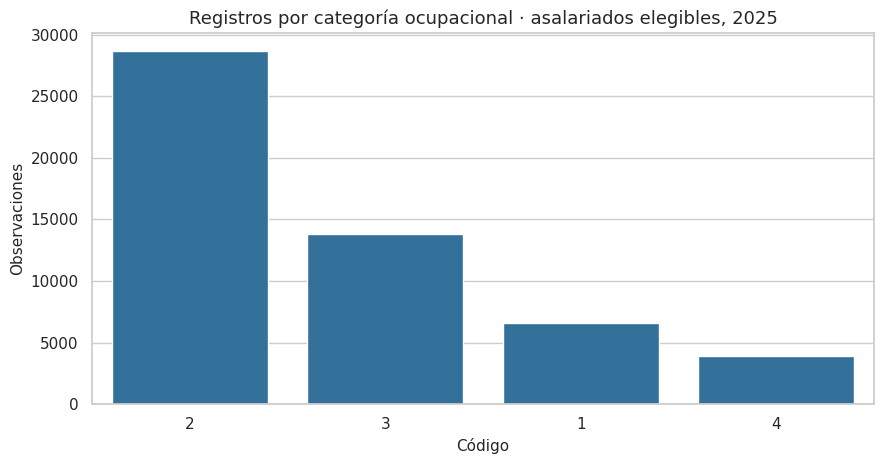

El grupo más frecuente es el código **2**, con **28,702 registros (54.1%)**. Las etiquetas de cada código se muestran arriba desde los diccionarios oficiales.

### Nivel educativo

,nivel_educativo,n,salario_mediano,porcentaje
4,4,16851,3600.0,31.78
2,2,15822,2200.0,29.84
3,3,8249,2800.0,15.56
5,5,6818,5000.0,12.86
0,0,3995,1500.0,7.53
6,6,771,10000.0,1.45
1,1,459,2160.0,0.87
7,7,60,12000.0,0.11


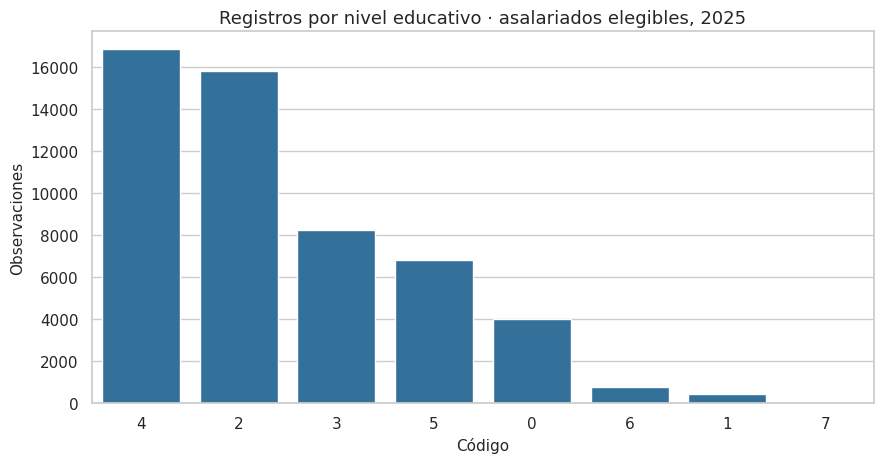

El grupo más frecuente es el código **4**, con **16,851 registros (31.8%)**. Las etiquetas de cada código se muestran arriba desde los diccionarios oficiales.

### Dominio

,dominio,n,salario_mediano,porcentaje
0,1,22072,3700.0,41.63
1,2,20146,2880.0,37.99
2,3,10807,2000.0,20.38


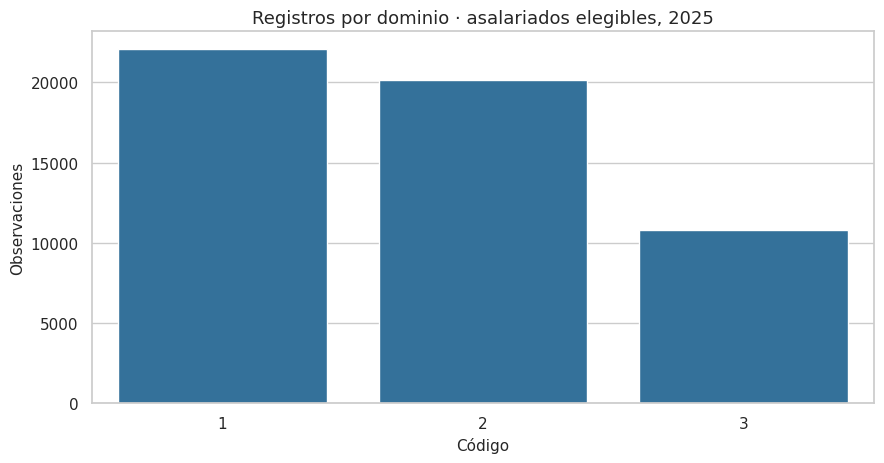

El grupo más frecuente es el código **1**, con **22,072 registros (41.6%)**. Las etiquetas de cada código se muestran arriba desde los diccionarios oficiales.

In [8]:
group_tables = {}
for column, label in [("categoria_ocupacional", "Categoría ocupacional"),
                      ("nivel_educativo", "Nivel educativo"), ("dominio", "Dominio")]:
    table = group_salary(train, column)
    table["porcentaje"] = 100 * table["n"] / train_n
    group_tables[column] = table.sort_values("n", ascending=False)
    display(Markdown(f"### {label}"))
    display(group_tables[column].round(2))
    fig, ax = plt.subplots()
    sns.barplot(data=group_tables[column], x=column, y="n", ax=ax, color="#2374ab")
    ax.set(title=f"Registros por {label.lower()} · asalariados elegibles, 2025", xlabel="Código", ylabel="Observaciones")
    plt.tight_layout(); plt.show()
    top = group_tables[column].iloc[0]
    display(Markdown(f"El grupo más frecuente es el código **{top[column]}**, con **{int(top['n']):,} registros ({top['porcentaje']:.1f}%)**. Las etiquetas de cada código se muestran arriba desde los diccionarios oficiales."))

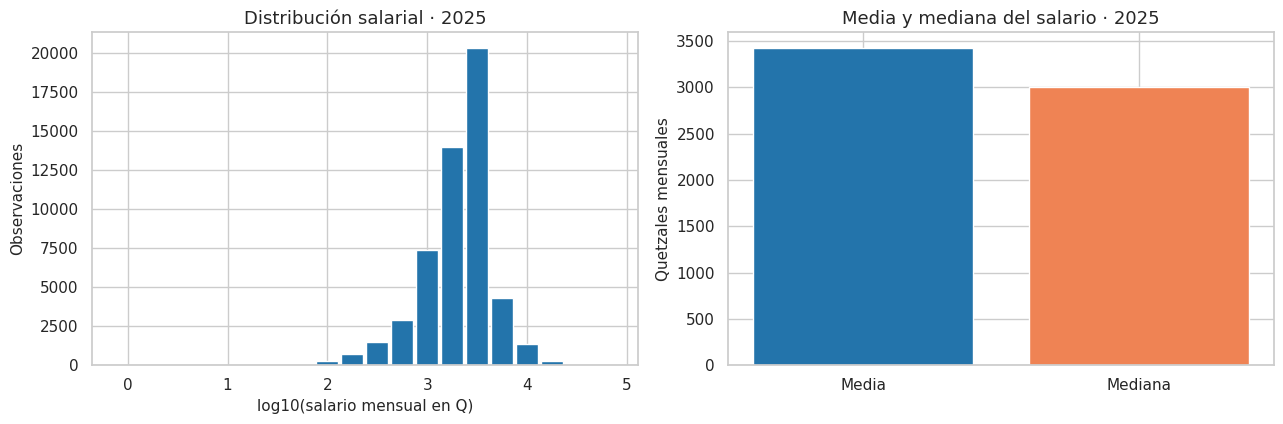

La distribución abarca desde **Q1.00** hasta **Q99,000.00**. El eje del histograma está en **log10** solo para visualizar; las estadísticas y el salario modelado permanecen en quetzales originales. Los valores altos no fueron eliminados.

In [9]:
# Histograma agregado en Spark. Los intervalos son de 0.25 unidades log10.
hist = (train.withColumn("log_bin", F.floor(F.log10("salario_mensual") * 4) / 4)
        .groupBy("log_bin").count().orderBy("log_bin").toPandas())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(hist["log_bin"], hist["count"], width=0.22, color="#2374ab")
axes[0].set(title="Distribución salarial · 2025", xlabel="log10(salario mensual en Q)", ylabel="Observaciones")
axes[1].bar(["Media", "Mediana"], [salary_row["media"], salary_row["mediana"]], color=["#2374ab", "#ef8354"])
axes[1].set(title="Media y mediana del salario · 2025", ylabel="Quetzales mensuales")
plt.tight_layout(); plt.show()
display(Markdown(f"La distribución abarca desde **Q{salary_row['minimo']:,.2f}** hasta **Q{salary_row['maximo']:,.2f}**. El eje del histograma está en **log10** solo para visualizar; las estadísticas y el salario modelado permanecen en quetzales originales. Los valores altos no fueron eliminados."))

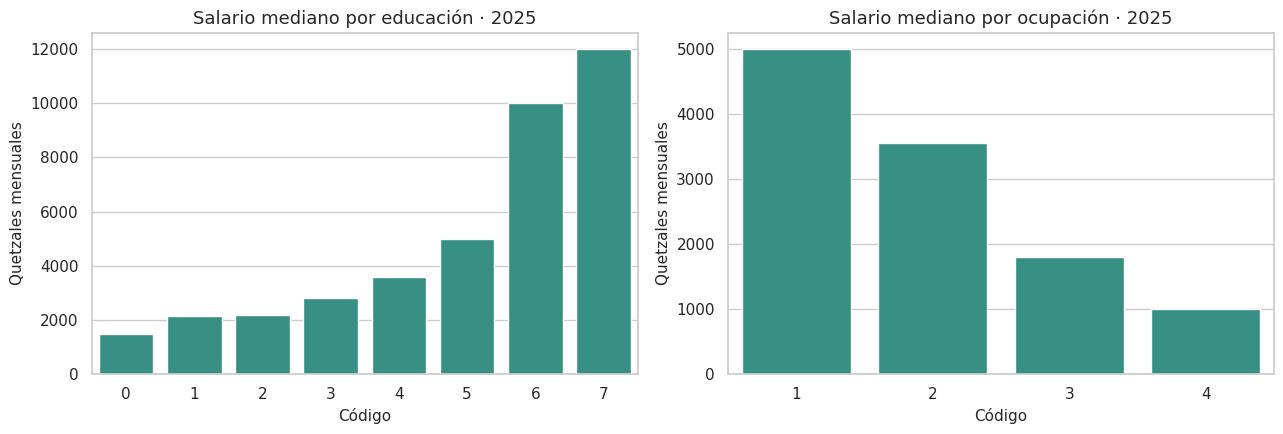

Por educación, la mediana mayor corresponde al código **7** (Q12,000.00; n=60) y la menor al código **0** (Q1,500.00; n=3,995). Estas son asociaciones descriptivas, no efectos causales.

Por ocupación, la mediana mayor corresponde al código **1** (Q5,000.00; n=6,575) y la menor al código **4** (Q1,000.00; n=3,906). Estas son asociaciones descriptivas, no efectos causales.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, column, title in [(axes[0], "nivel_educativo", "Salario mediano por educación"),
                          (axes[1], "categoria_ocupacional", "Salario mediano por ocupación")]:
    table = group_tables[column].sort_values(column)
    sns.barplot(data=table, x=column, y="salario_mediano", ax=ax, color="#2a9d8f")
    ax.set(title=title + " · 2025", xlabel="Código", ylabel="Quetzales mensuales")
plt.tight_layout(); plt.show()
for column, name in [("nivel_educativo", "educación"), ("categoria_ocupacional", "ocupación")]:
    table = group_tables[column]
    highest = table.loc[table["salario_mediano"].idxmax()]
    lowest = table.loc[table["salario_mediano"].idxmin()]
    display(Markdown(f"Por {name}, la mediana mayor corresponde al código **{highest[column]}** (Q{highest['salario_mediano']:,.2f}; n={int(highest['n']):,}) y la menor al código **{lowest[column]}** (Q{lowest['salario_mediano']:,.2f}; n={int(lowest['n']):,}). Estas son asociaciones descriptivas, no efectos causales."))

,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


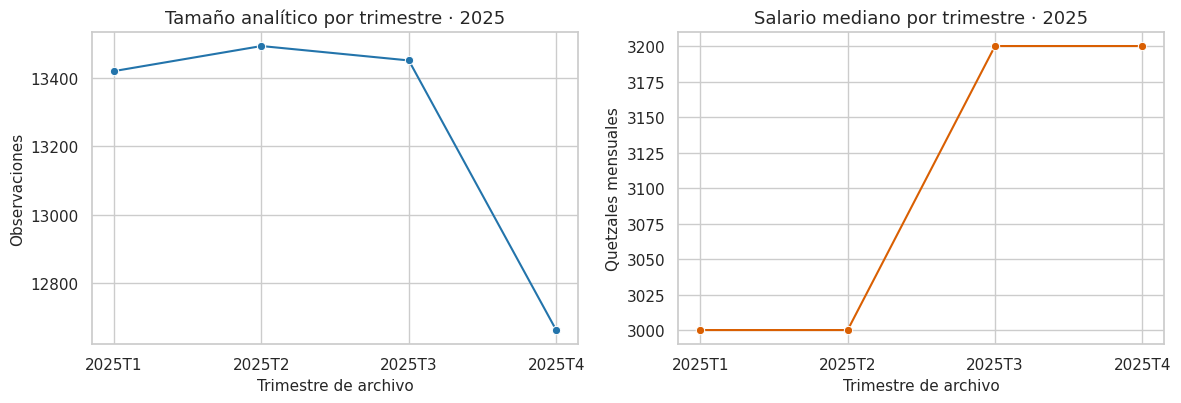

De 2025T1 a 2025T4, el tamaño cambió de **13,419** a **12,664** observaciones y el salario mediano de **Q3,000.00** a **Q3,200.00**. Son cortes de archivo y no un panel balanceado de personas únicas.

In [11]:
quarters = group_salary(train, "periodo_archivo").sort_values("periodo_archivo")
display(quarters)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.lineplot(data=quarters, x="periodo_archivo", y="n", marker="o", ax=axes[0], color="#2374ab")
sns.lineplot(data=quarters, x="periodo_archivo", y="salario_mediano", marker="o", ax=axes[1], color="#d95f02")
axes[0].set(title="Tamaño analítico por trimestre · 2025", xlabel="Trimestre de archivo", ylabel="Observaciones")
axes[1].set(title="Salario mediano por trimestre · 2025", xlabel="Trimestre de archivo", ylabel="Quetzales mensuales")
plt.tight_layout(); plt.show()
first, last = quarters.iloc[0], quarters.iloc[-1]
display(Markdown(f"De {first['periodo_archivo']} a {last['periodo_archivo']}, el tamaño cambió de **{int(first['n']):,}** a **{int(last['n']):,}** observaciones y el salario mediano de **Q{first['salario_mediano']:,.2f}** a **Q{last['salario_mediano']:,.2f}**. Son cortes de archivo y no un panel balanceado de personas únicas."))

## 3. Relaciones numéricas

Pearson mide asociación **lineal**. Se calcula sobre todos los registros elegibles de 2025 usando `VectorAssembler` y `Correlation.corr()` de Spark. Los extremos salariales pueden influir en los coeficientes; un coeficiente no demuestra causalidad.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


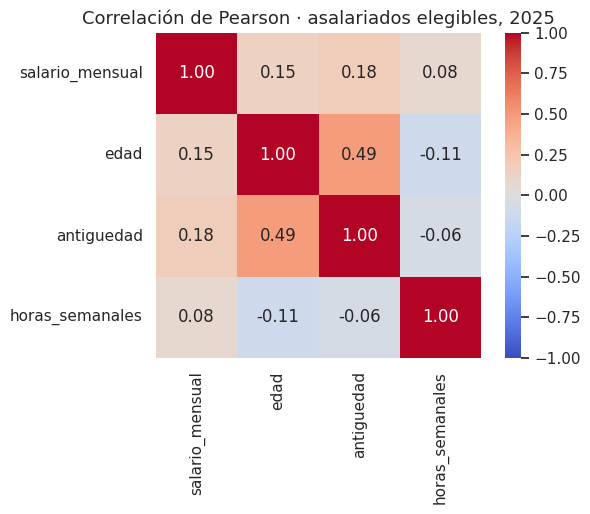

La mayor asociación lineal absoluta con salario corresponde a **antiguedad** (r=0.180). Edad y antigüedad tienen r=**0.487**. Los resultados se refieren a las observaciones elegibles y no establecen causas.

In [12]:
corr_cols = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
corr_input = VectorAssembler(inputCols=corr_cols, outputCol="corr_features").transform(train.select(*corr_cols))
matrix = Correlation.corr(corr_input, "corr_features", "pearson").first()[0].toArray()
corr_table = pd.DataFrame(matrix, index=corr_cols, columns=corr_cols)
display(corr_table.round(3))
fig, ax = plt.subplots(figsize=(6.6, 5.3))
sns.heatmap(corr_table, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlación de Pearson · asalariados elegibles, 2025")
plt.tight_layout(); plt.show()
salary_corr = corr_table.loc["salario_mensual"].drop("salario_mensual")
strongest = salary_corr.abs().idxmax()
display(Markdown(f"La mayor asociación lineal absoluta con salario corresponde a **{strongest}** (r={salary_corr[strongest]:.3f}). Edad y antigüedad tienen r=**{corr_table.loc['edad','antiguedad']:.3f}**. Los resultados se refieren a las observaciones elegibles y no establecen causas."))

## 4. Segmentación KMeans

Se comparan dos espacios de variables: perfil laboral (`edad`, `antiguedad`, `horas_semanales`) y sensibilidad con salario añadido. La primera define los perfiles principales; en ella el salario se usa **solo para caracterizarlos**. Se estandariza cada variable para evitar que su unidad domine la distancia. Para cada variante se prueban K=2–5 y tres semillas. El K con silhouette media más alta es seleccionado; si otro K está a menos de 0.01, se prefiere el menor. La silhouette de espacios distintos no se compara como prueba directa de superioridad.

In [13]:
variants = {
    "perfil_laboral": ["edad", "antiguedad", "horas_semanales"],
    "con_salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
}
seeds = [42, 123, 2026]
evaluator = ClusteringEvaluator(featuresCol="features_scaled", predictionCol="prediction",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")
experiments = []
fitted = {}
variant_stages = {}
for variant, columns in variants.items():
    assembler = VectorAssembler(inputCols=columns, outputCol="features_raw")
    scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=True, withStd=True)
    scaler_model = scaler.fit(assembler.transform(train))
    scaled = scaler_model.transform(assembler.transform(train)).cache()
    scaled.count()
    variant_stages[variant] = (assembler, scaler_model)
    for k in [2, 3, 4, 5]:
        for seed in seeds:
            model = KMeans(featuresCol="features_scaled", predictionCol="prediction",
                           k=k, seed=seed, maxIter=100, tol=1e-4).fit(scaled)
            predicted = model.transform(scaled)
            silhouette = float(evaluator.evaluate(predicted))
            sizes = {int(r.prediction): int(r["count"]) for r in predicted.groupBy("prediction").count().collect()}
            cost = float(model.summary.trainingCost)
            experiments.append({"variante": variant, "K": k, "semilla": seed,
                                "silhouette": silhouette, "costo": cost,
                                "tamano_minimo": min(sizes.values()), "tamanos": sizes})
            fitted[(variant, k, seed)] = model
            print(variant, "K=", k, "semilla=", seed, "silhouette=", round(silhouette, 4), "tamaños=", sizes, flush=True)
    scaled.unpersist()
experiments_df = pd.DataFrame(experiments)
display(experiments_df)

perfil_laboral K= 2 semilla= 42 silhouette= 0.5545 tamaños= {1: 38421, 0: 14604}


perfil_laboral K= 2 semilla= 123 silhouette= 0.5547 tamaños= {1: 14586, 0: 38439}


perfil_laboral K= 2 semilla= 2026 silhouette= 0.5545 tamaños= {1: 38421, 0: 14604}


perfil_laboral K= 3 semilla= 42 silhouette= 0.4429 tamaños= {1: 7177, 2: 16348, 0: 29500}


perfil_laboral K= 3 semilla= 123 silhouette= 0.4429 tamaños= {1: 29500, 2: 7177, 0: 16348}


...

con_salario K= 4 semilla= 2026 silhouette= 0.3753 tamaños= {3: 17029, 1: 26533, 2: 2336, 0: 7127}


con_salario K= 5 semilla= 42 silhouette= 0.3732 tamaños= {3: 7038, 1: 6586, 4: 10548, 2: 22603, 0: 6250}


con_salario K= 5 semilla= 123 silhouette= 0.3836 tamaños= {1: 6331, 3: 8494, 2: 25045, 4: 2096, 0: 11059}


con_salario K= 5 semilla= 2026 silhouette= 0.4137 tamaños= {3: 6321, 1: 2093, 2: 11484, 4: 8889, 0: 24238}


,variante,K,semilla,silhouette,costo,tamano_minimo,tamanos
0,perfil_laboral,2,42,0.554482,106717.388047,14604,"{1: 38421, 0: 14604}"
1,perfil_laboral,2,123,0.554736,106717.386143,14586,"{1: 14586, 0: 38439}"
2,perfil_laboral,2,2026,0.554482,106717.388047,14604,"{1: 38421, 0: 14604}"
3,perfil_laboral,3,42,0.442878,84468.146181,7177,"{1: 7177, 2: 16348, 0: 29500}"
4,perfil_laboral,3,123,0.442878,84468.146181,7177,"{1: 29500, 2: 7177, 0: 16348}"
5,perfil_laboral,3,2026,0.442878,84468.146181,7177,"{1: 29500, 2: 16348, 0: 7177}"
6,perfil_laboral,4,42,0.474663,64437.033426,6846,"{1: 6846, 3: 24400, 2: 12524, 0: 9255}"
7,perfil_laboral,4,123,0.476037,64438.208032,6867,"{1: 6867, 3: 8928, 2: 24488, 0: 12742}"
8,perfil_laboral,4,2026,0.476037,64438.208032,6867,"{3: 12742, 1: 24488, 2: 8928, 0: 6867}"
9,perfil_laboral,5,42,0.491153,56848.446853,2615,"{1: 10290, 3: 2615, 2: 7528, 4: 24100, 0: 8492}"


### perfil_laboral: K=2, semilla=123

,mean,min,max
K,,,
2,0.5546,0.5545,0.5547
3,0.4429,0.4429,0.4429
4,0.4756,0.4747,0.4760
5,0.4863,0.4838,0.4912


Silhouette media por semilla para K elegido: **0.5546** (rango 0.5545–0.5547). Tamaño mínimo del ajuste elegido: **14,586** (27.51%).

### con_salario: K=2, semilla=42

,mean,min,max
K,,,
2,0.5147,0.5146,0.5148
3,0.3959,0.3372,0.4890
4,0.3736,0.3701,0.3753
5,0.3902,0.3732,0.4137


Silhouette media por semilla para K elegido: **0.5147** (rango 0.5146–0.5148). Tamaño mínimo del ajuste elegido: **14,319** (27.00%).

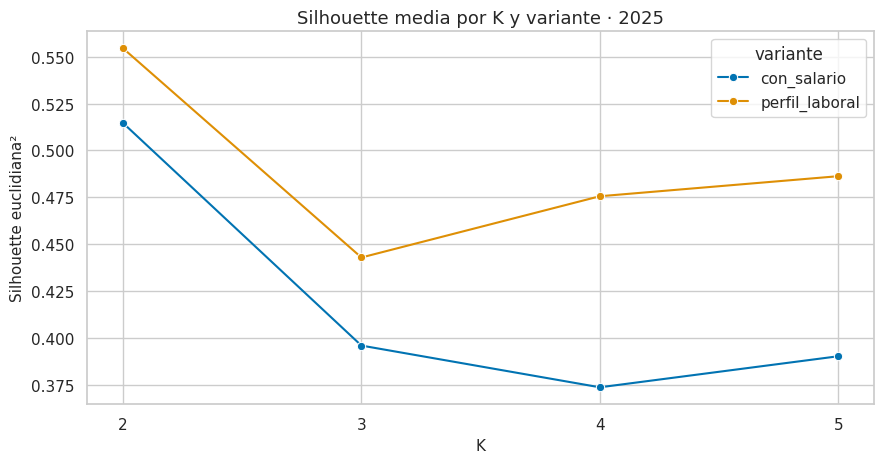

In [14]:
chosen = {}
for variant in variants:
    subset = experiments_df.loc[experiments_df.variante == variant]
    average = subset.groupby("K")["silhouette"].agg(["mean", "min", "max"])
    best_mean = average["mean"].max()
    chosen_k = min(int(k) for k in average.index if best_mean - average.loc[k, "mean"] <= 0.01)
    candidates = subset.loc[subset.K == chosen_k].sort_values(["silhouette", "semilla"], ascending=[False, True])
    winner = candidates.iloc[0]
    chosen[variant] = {"K": chosen_k, "semilla": int(winner.semilla), "silhouette": float(winner.silhouette)}
    display(Markdown(f"### {variant}: K={chosen_k}, semilla={int(winner.semilla)}"))
    display(average.round(4))
    display(Markdown(f"Silhouette media por semilla para K elegido: **{average.loc[chosen_k,'mean']:.4f}** (rango {average.loc[chosen_k,'min']:.4f}–{average.loc[chosen_k,'max']:.4f}). Tamaño mínimo del ajuste elegido: **{int(winner.tamano_minimo):,}** ({winner.tamano_minimo/train_n:.2%})."))
fig, ax = plt.subplots()
sns.lineplot(data=experiments_df.groupby(["variante", "K"], as_index=False)["silhouette"].mean(),
             x="K", y="silhouette", hue="variante", marker="o", ax=ax)
ax.set(title="Silhouette media por K y variante · 2025", ylabel="Silhouette euclidiana²", xticks=[2,3,4,5])
plt.tight_layout(); plt.show()

In [15]:
variant = "perfil_laboral"
choice = chosen[variant]
assembler, scaler_model = variant_stages[variant]
best_model = fitted[(variant, choice["K"], choice["semilla"])]
pipeline = PipelineModel(stages=[assembler, scaler_model, best_model])
assignments = pipeline.transform(train).cache()
assert assignments.count() == train_n
artifact_dir = ROOT / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
pipeline.write().overwrite().save(str(artifact_dir / "kmeans_perfil_laboral"))
assignments.select(*KEY, "prediction").write.mode("overwrite").parquet(str(artifact_dir / "asignaciones_2025.parquet"))
profile_spark = assignments.groupBy("prediction").agg(
    F.count("*").alias("n"),
    *[F.avg(c).alias(f"media_{c}") for c in ["edad", "antiguedad", "horas_semanales", "salario_mensual"]],
    *[F.expr(f"percentile_approx({c}, 0.5, 10000)").alias(f"mediana_{c}")
      for c in ["edad", "antiguedad", "horas_semanales", "salario_mensual"]],
).orderBy("prediction")
profiles = profile_spark.toPandas()
profiles["porcentaje"] = 100 * profiles["n"] / train_n
display(profiles.round(2))
assert profiles.n.sum() == train_n

,prediction,n,media_edad,media_antiguedad,media_horas_semanales,media_salario_mensual,mediana_edad,mediana_antiguedad,mediana_horas_semanales,mediana_salario_mensual,porcentaje
0,0,38439,29.08,2.42,48.21,3175.68,28.0,1.33,46.0,3000.0,72.49
1,1,14586,51.29,13.82,41.31,4069.99,51.0,13.00,40.0,3466.0,27.51


In [16]:
composition = {}
for group in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    table = (assignments.groupBy("prediction", group).count()
             .withColumn("porcentaje_cluster", F.col("count") * 100 / F.sum("count").over(
                 __import__("pyspark").sql.Window.partitionBy("prediction")))
             .orderBy("prediction", F.desc("count")).toPandas())
    composition[group] = table
    display(Markdown(f"### Composición por {group}"))
    display(table.round(2))
profile_numeric = profiles.set_index("prediction")
overall = {c: float(summary.set_index("variable").loc[c, "media"]) for c in ["edad", "antiguedad", "horas_semanales"]}
names = {}
for row in profiles.itertuples():
    parts = []
    for label, field in [("edad", "edad"), ("antigüedad", "antiguedad"), ("jornada", "horas_semanales")]:
        ratio = getattr(row, f"media_{field}") / overall[field]
        parts.append(f"{label} {'alta' if ratio > 1.1 else 'baja' if ratio < 0.9 else 'intermedia'}")
    names[int(row.prediction)] = ", ".join(parts)
    display(Markdown(f"**Cluster {row.prediction}: {names[int(row.prediction)]}.** n={row.n:,} ({row.porcentaje:.1f}%), edad media {row.media_edad:.1f} años, antigüedad media {row.media_antiguedad:.1f} años, jornada media {row.media_horas_semanales:.1f} h/semana y salario mediano Q{row.mediana_salario_mensual:,.2f}."))

### Composición por nivel_educativo

,prediction,nivel_educativo,count,porcentaje_cluster
0,0,4,13563,35.28
1,0,2,11080,28.82
2,0,3,6856,17.84
3,0,5,4330,11.26
4,0,0,1881,4.89
5,0,6,426,1.11
6,0,1,291,0.76
7,0,7,12,0.03
8,1,2,4742,32.51
9,1,4,3288,22.54


### Composición por categoria_ocupacional

,prediction,categoria_ocupacional,count,porcentaje_cluster
0,0,2,22498,58.53
1,0,3,10296,26.79
2,0,1,3146,8.18
3,0,4,2499,6.50
4,1,2,6204,42.53
5,1,3,3546,24.31
6,1,1,3429,23.51
7,1,4,1407,9.65


### Composición por dominio

,prediction,dominio,count,porcentaje_cluster
0,0,1,15441,40.17
1,0,2,14669,38.16
2,0,3,8329,21.67
3,1,1,6631,45.46
4,1,2,5477,37.55
5,1,3,2478,16.99


**Cluster 0: edad baja, antigüedad baja, jornada intermedia.** n=38,439 (72.5%), edad media 29.1 años, antigüedad media 2.4 años, jornada media 48.2 h/semana y salario mediano Q3,000.00.

**Cluster 1: edad alta, antigüedad alta, jornada baja.** n=14,586 (27.5%), edad media 51.3 años, antigüedad media 13.8 años, jornada media 41.3 h/semana y salario mediano Q3,466.00.

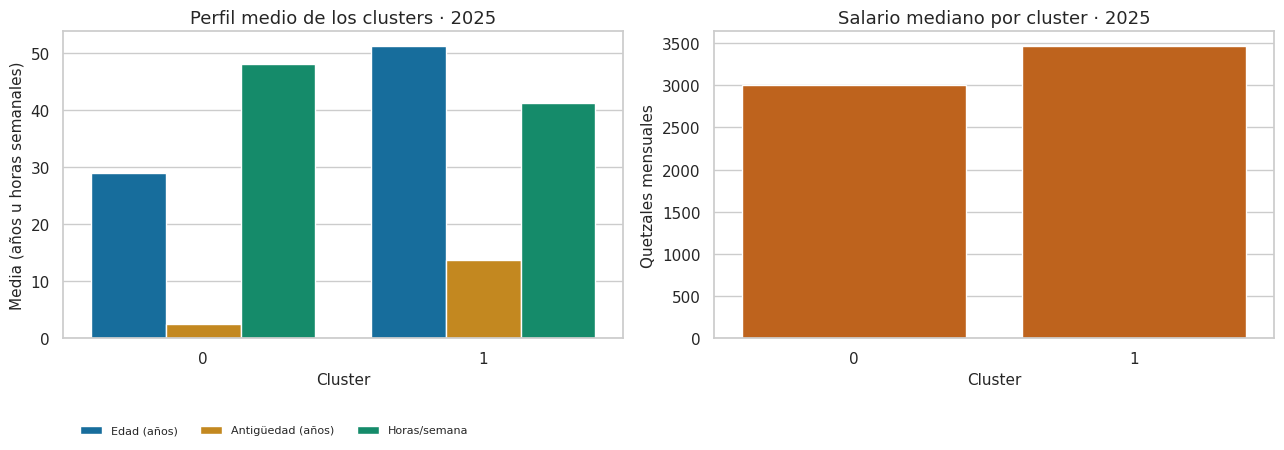

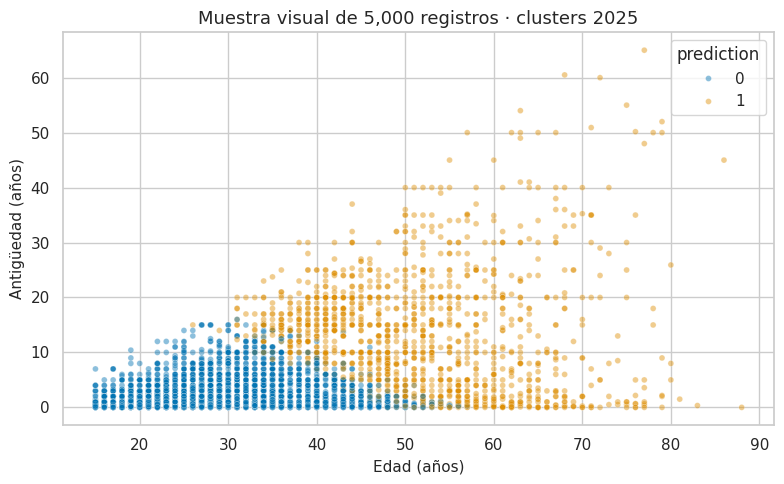

La variante con salario evalúa sensibilidad del agrupamiento. Su silhouette corresponde a un espacio de cuatro variables y no es directamente comparable con la de tres variables. Los perfiles principales se interpretan por edad, antigüedad y horas; sus diferencias salariales son descriptivas.

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
profile_long = profiles.melt(id_vars="prediction", value_vars=["media_edad", "media_antiguedad", "media_horas_semanales"],
                              var_name="caracteristica", value_name="media")
sns.barplot(data=profile_long, x="prediction", y="media", hue="caracteristica", ax=axes[0])
axes[0].set(title="Perfil medio de los clusters · 2025", xlabel="Cluster", ylabel="Media (años u horas semanales)")
legend_handles, _ = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
fig.legend(legend_handles, ["Edad (años)", "Antigüedad (años)", "Horas/semana"],
           loc="lower left", bbox_to_anchor=(0.06, -0.01), ncol=3, fontsize=8, frameon=False)
sns.barplot(data=profiles, x="prediction", y="mediana_salario_mensual", ax=axes[1], color="#d95f02")
axes[1].set(title="Salario mediano por cluster · 2025", xlabel="Cluster", ylabel="Quetzales mensuales")
plt.tight_layout(rect=(0, 0.08, 1, 1)); plt.show()
sample = (assignments.orderBy(F.rand(42))
          .select("edad", "antiguedad", "horas_semanales", "salario_mensual", "prediction")
          .limit(5000).toPandas())
assert len(sample) <= 5000
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="edad", y="antiguedad", hue="prediction", alpha=0.45, s=18, ax=ax)
ax.set(title="Muestra visual de 5,000 registros · clusters 2025", xlabel="Edad (años)", ylabel="Antigüedad (años)")
plt.tight_layout(); plt.show()
display(Markdown("La variante con salario evalúa sensibilidad del agrupamiento. Su silhouette corresponde a un espacio de cuatro variables y no es directamente comparable con la de tres variables. Los perfiles principales se interpretan por edad, antigüedad y horas; sus diferencias salariales son descriptivas."))

### Sensibilidad a incluir salario

Comparamos las asignaciones de las dos variantes para los mismos registros, sin confundir los identificadores de cluster (que pueden intercambiarse entre ajustes). La tabla muestra cuántas observaciones conservan su agrupación después de alinear las etiquetas. También se describe el salario de los grupos resultantes; esta comparación ayuda a decidir si añadirlo cambia el significado de los perfiles.

,prediction,n,edad_media,antiguedad_media,horas_medias,salario_mediano
0,0,14319,50.75,14.08,42.09,3750.0
1,1,38706,29.43,2.41,47.87,3000.0


con_salario,0,1
perfil,,
0,1096,37343
1,13223,1363


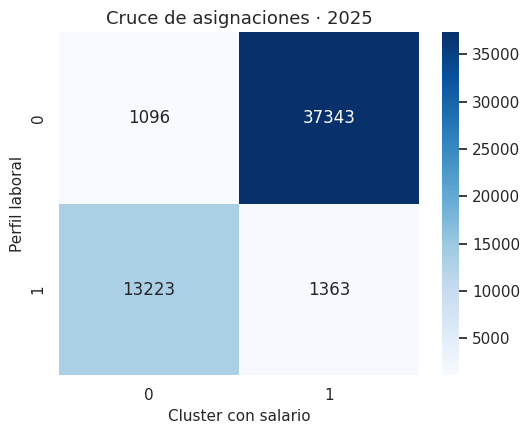

Tras alinear las etiquetas, **95.4%** de las observaciones permanecen en el mismo grupo y **4.6%** cambian. La variante con salario produce grupos de tamaño 14,319, 38,706. Dado que el objetivo es describir perfiles de edad, antigüedad y jornada sin definirlos por el ingreso, se conserva la variante laboral como principal. El salario se reporta aparte para comparar los perfiles; su inclusión modifica los grupos en la proporción observada arriba.

In [18]:
salary_choice = chosen["con_salario"]
salary_assembler, salary_scaler = variant_stages["con_salario"]
salary_model = fitted[("con_salario", salary_choice["K"], salary_choice["semilla"])]
salary_pipeline = PipelineModel(stages=[salary_assembler, salary_scaler, salary_model])
salary_clusters = salary_pipeline.transform(train).cache()
salary_clusters.count()
salary_profile = (salary_clusters.groupBy("prediction")
                  .agg(F.count("*").alias("n"), F.avg("edad").alias("edad_media"),
                       F.avg("antiguedad").alias("antiguedad_media"),
                       F.avg("horas_semanales").alias("horas_medias"),
                       F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"))
                  .orderBy("prediction").toPandas())
display(salary_profile.round(2))
cross = (assignments.select(*KEY, F.col("prediction").alias("perfil"))
         .join(salary_clusters.select(*KEY, F.col("prediction").alias("con_salario")), KEY)
         .groupBy("perfil", "con_salario").count().toPandas())
cross_table = cross.pivot(index="perfil", columns="con_salario", values="count").fillna(0).astype(int)
display(cross_table)
assert cross_table.to_numpy().sum() == train_n
counts = cross_table.to_numpy()
agreement = max(counts[0,0] + counts[1,1], counts[0,1] + counts[1,0]) / train_n
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cross_table, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set(title="Cruce de asignaciones · 2025", xlabel="Cluster con salario", ylabel="Perfil laboral")
plt.tight_layout(); plt.show()
display(Markdown(f"Tras alinear las etiquetas, **{agreement:.1%}** de las observaciones permanecen en el mismo grupo y **{1-agreement:.1%}** cambian. La variante con salario produce grupos de tamaño {', '.join(f'{int(x):,}' for x in salary_profile.n)}. Dado que el objetivo es describir perfiles de edad, antigüedad y jornada sin definirlos por el ingreso, se conserva la variante laboral como principal. El salario se reporta aparte para comparar los perfiles; su inclusión modifica los grupos en la proporción observada arriba."))
_ = salary_clusters.unpersist()

## Síntesis del avance

El notebook deja trazabilidad del origen, esquema, pérdida por filtros, distribuciones, correlaciones y selección de K. Las observaciones longitudinales no se convierten en individuos únicos. Los patrones de salario y clusters son asociaciones de registros elegibles, sin lectura causal o poblacional. La preparación 2026 queda almacenada para los incisos 5–8, pero no participa en resultados de este avance.

In [19]:
assert train_n > 0 and test_n > 0
assert all(len(experiments_df.loc[experiments_df.variante == v]) == 12 for v in variants)
assert set(train.select("periodo_archivo").distinct().toPandas()["periodo_archivo"]) == set(periodos[:4])
assert set(test_2026.select("periodo_archivo").distinct().toPandas()["periodo_archivo"]) == {"2026T1"}
print("Validaciones finales superadas. Registros 2025:", train_n, "; registros 2026T1:", test_n)

Validaciones finales superadas. Registros 2025: 53025 ; registros 2026T1: 13258
